# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/eauvero/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    try:
        X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32) 
        y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32) - 1
        
        X_test  = np.loadtxt(os.path.join(root_dir, "test",  "X_test.txt"), dtype=np.float32)
        y_test  = np.loadtxt(os.path.join(root_dir, "test",  "y_test.txt"), dtype=np.int32) - 1

        return X_train, y_train, X_test, y_test
    except:
        raise Exception("Failed to load HAR test and training data.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

# <-- Enter your code here <--#
num_features = 561
num_classes = 6

print("Training set:", X_train.shape, y_train.shape)
print("Test set    :", X_test.shape, y_test.shape)
print("Input dtype :", X_train.dtype)
print("Label dtype :", y_train.dtype)

print("# features :", X_train.shape[1])
print("# classes :", len(np.unique(y_train)))

Training set: (7352, 561) (7352,)
Test set    : (2947, 561) (2947,)
Input dtype : float32
Label dtype : int32
# features : 561
# classes : 6


## 4. Quick Inspection

In [4]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#
indices, counts = np.unique(y_train, return_counts=True)
print(" " * 48)
print("-" * 48)
print(f"{'Class Index':<12} | {'Class Name':<20} | {'# Samples':<8}")
print("-" * 48)

for ind, count in zip(indices, counts):
    print(f"{ind:<12} | {class_names[ind]:<20} | {count:<8}")

                                                
------------------------------------------------
Class Index  | Class Name           | # Samples
------------------------------------------------
0            | WALKING              | 1226    
1            | WALKING_UPSTAIRS     | 1073    
2            | WALKING_DOWNSTAIRS   | 986     
3            | SITTING              | 1286    
4            | STANDING             | 1374    
5            | LAYING               | 1407    


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [5]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0712 - accuracy: 0.9723 - val_loss: 0.2235 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0588 - accuracy: 0.9776 - val_loss: 0.1442 - val_accuracy: 0.9422
Epoch 8/40
92/92 [==

### Training Curves

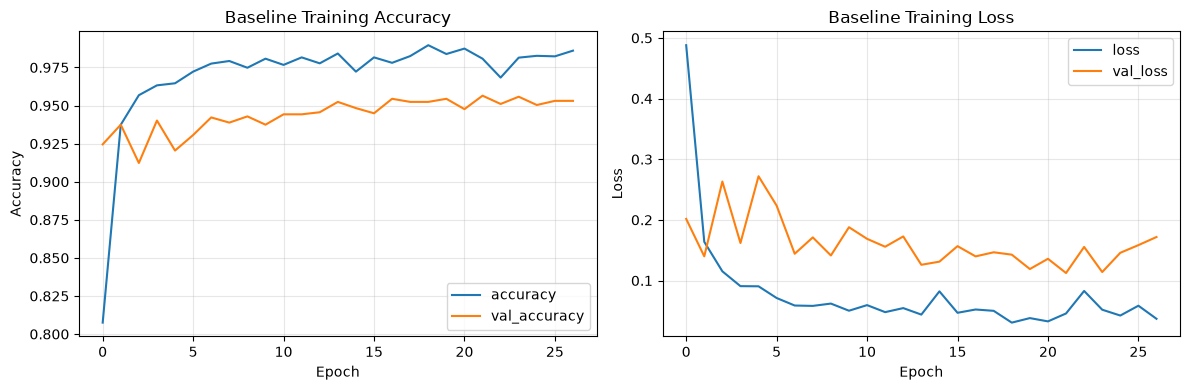

In [7]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#

history_df = pd.DataFrame(baseline_history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


history_df[["accuracy", "val_accuracy"]].plot(ax=axes[0], title="Baseline Training Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)

history_df[["loss", "val_loss"]].plot(ax=axes[1], title="Baseline Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

Baseline Test Accuracy: 0.9264

                    precision    recall  f1-score   support

           WALKING     0.8591    0.9960    0.9225       496
  WALKING_UPSTAIRS     0.9525    0.8514    0.8991       471
WALKING_DOWNSTAIRS     0.9721    0.9119    0.9410       420
           SITTING     0.9315    0.8859    0.9081       491
          STANDING     0.8724    0.9380    0.9040       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9264      2947
         macro avg     0.9313    0.9246    0.9261      2947
      weighted avg     0.9303    0.9264    0.9265      2947



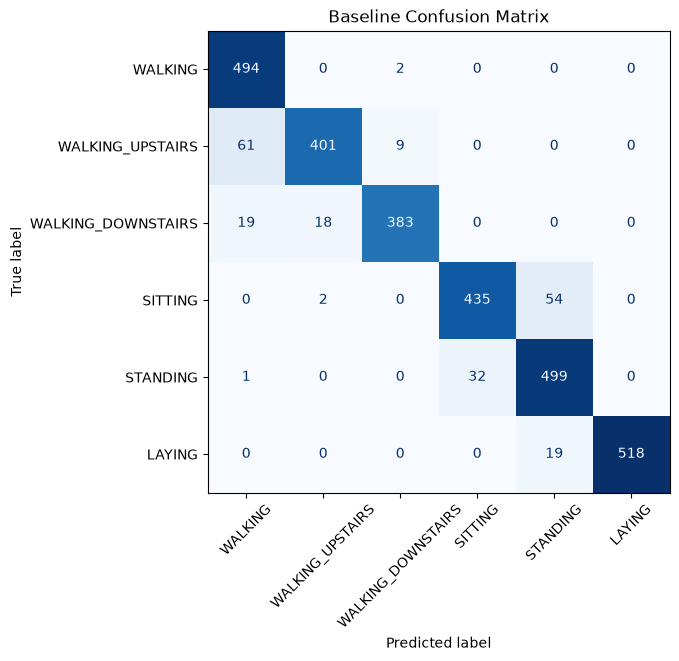

In [8]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


probs = baseline_model.predict(X_test, verbose=0)
preds = np.argmax(probs, axis=1)
test_acc = accuracy_score(y_test, preds)

print(f"Baseline Test Accuracy: {test_acc:.4f}\n")
print(classification_report(y_test, preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, preds),
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Confusion Matrix")
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [9]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        # <-- Enter your code here <--#
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.

    # <-- Enter your code here <--#
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [10]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# <-- Enter your code here <--#

fp32_tflite_model = convert_to_tflite_fp32(baseline_model)
fp32_size_kb = save_binary_model(fp32_tflite_model, "baseline_no_pruning_fp32.tflite")
fp32_acc, fp32_preds = evaluate_tflite_model(fp32_tflite_model, X_test, y_test)

INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp8y2v5su_/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp8y2v5su_/assets
2026-07-15 19:54:18.288145: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 19:54:18.288157: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 19:54:18.288302: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp8y2v5su_
2026-07-15 19:54:18.288696: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 19:54:18.288699: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmp8y2v5su_
2026-07-15 19:54:18.289466: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-07-15 19:54:18.289822: I tensorflow/cc/saved_model/load

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [11]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#

steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#

pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#

pruning_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)


Epoch 1/12
92/92 [==============================] - 1s 2ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1662 - accuracy: 0.9367 - val_loss: 0.1591 - val_accuracy: 0.9293
Epoch 3/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1314 - accuracy: 0.9493 - val_loss: 0.2293 - val_accuracy: 0.9252
Epoch 4/12
92/92 [==============================] - 0s 1ms/step - loss: 0.0901 - accuracy: 0.9699 - val_loss: 0.1750 - val_accuracy: 0.9334
Epoch 5/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1388 - accuracy: 0.9476 - val_loss: 0.1383 - val_accuracy: 0.9415
Epoch 6/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1209 - accuracy: 0.9607 - val_loss: 0.1783 - val_accuracy: 0.9347
Epoch 7/12
92/92 [==============================] - 0s 1ms/step - loss: 0.3121 - accuracy: 0.9255 - val_loss: 0.1751 - val_accuracy: 0.9334
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [12]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#

pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite,"pruned_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)


stripped_model = strip_pruning(pruned_model)
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()
stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpp1zz0kpf/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpp1zz0kpf/assets
2026-07-15 19:54:21.381241: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 19:54:21.381255: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 19:54:21.381327: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpp1zz0kpf
2026-07-15 19:54:21.382391: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 19:54:21.382395: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpp1zz0kpf
2026-07-15 19:54:21.385387: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 19:54:21.408799: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpk7s5nf55/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpk7s5nf55/assets
2026-07-15 19:54:21.823458: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 19:54:21.823468: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 19:54:21.823534: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpk7s5nf55
2026-07-15 19:54:21.823765: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 19:54:21.823768: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpk7s5nf55
2026-07-15 19:54:21.824304: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 19:54:21.830507: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 11. Part I Comparison: Accuracy and Model Size

In [13]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#

def build_results_table(rows):
    df = pd.DataFrame(rows)
    df["size_kb"] = df["size_kb"].round(2)
    df["accuracy"] = df["accuracy"].round(6)
    return df

prune_rows = []

for model_name, model_format, model_acc, model_size in [
    ("Baseline FP32 TFLite", "float32", fp32_acc, fp32_size_kb),
    ("Pruned FP32 TFLite With Mask", "float32", pruned_with_mask_acc, pruned_with_mask_size_kb),
    ("Stripped Sparse FP32 TFLite", "float32", stripped_sparse_acc, stripped_sparse_size_kb),
]:
    prune_rows.append(
        {
            "model family": model_name,
            "format": model_format,
            "accuracy": model_acc,
            "size_kb": model_size,
        }
    )

prune_results = build_results_table(prune_rows)
prune_results


,model family,format,accuracy,size_kb
0,Baseline FP32 TFLite,float32,0.926366,726.72
1,Pruned FP32 TFLite With Mask,float32,0.937564,1454.18
2,Stripped Sparse FP32 TFLite,float32,0.937564,162.99


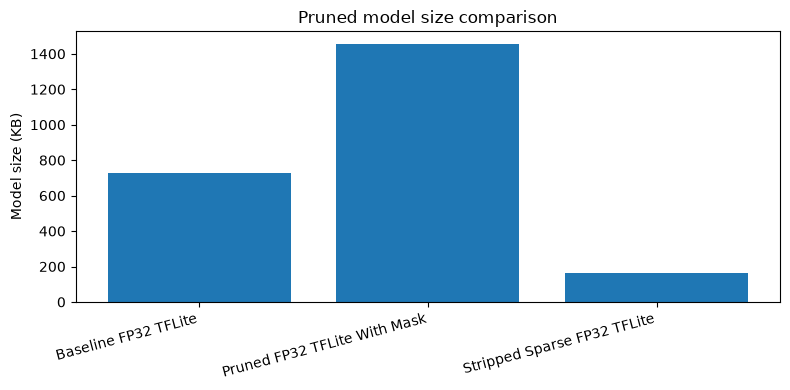

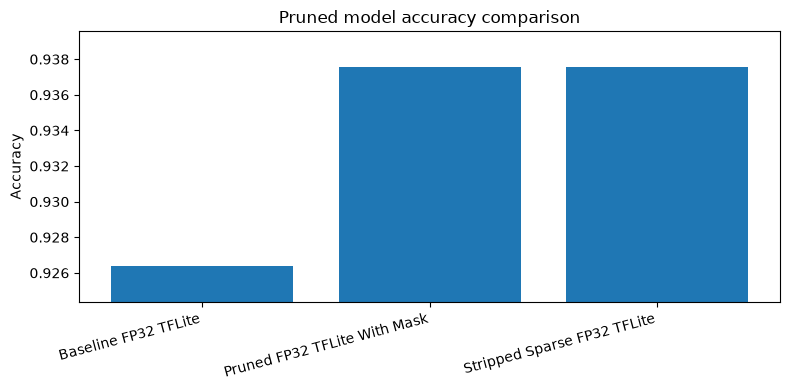

In [14]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#


prune_plot_df = prune_results.copy()

plt.figure(figsize=(8, 4))
plt.bar(prune_plot_df["model family"], prune_plot_df["size_kb"])
plt.ylabel("Model size (KB)")
plt.title("Pruned model size comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(prune_plot_df["model family"], prune_plot_df["accuracy"])
plt.ylabel("Accuracy")
plt.ylim(max(0.0, prune_plot_df["accuracy"].min() - 0.002), min(1.0, prune_plot_df["accuracy"].max() + 0.002))
plt.title("Pruned model accuracy comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

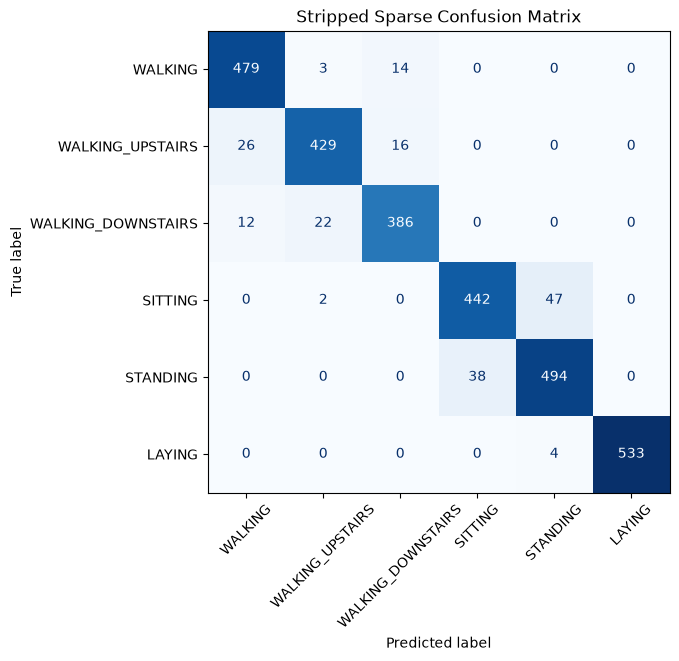

Stripped Sparse Test Accuracy: 0.9376

                    precision    recall  f1-score   support

           WALKING     0.9265    0.9657    0.9457       496
  WALKING_UPSTAIRS     0.9408    0.9108    0.9256       471
WALKING_DOWNSTAIRS     0.9279    0.9190    0.9234       420
           SITTING     0.9208    0.9002    0.9104       491
          STANDING     0.9064    0.9286    0.9174       532
            LAYING     1.0000    0.9926    0.9963       537

          accuracy                         0.9376      2947
         macro avg     0.9371    0.9362    0.9365      2947
      weighted avg     0.9378    0.9376    0.9375      2947



In [15]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_preds),
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse Confusion Matrix")
plt.show()


print(f"Stripped Sparse Test Accuracy: {stripped_sparse_acc:.4f}\n")
print(classification_report(y_test, stripped_sparse_preds, target_names=class_names, digits=4))

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [16]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()


pruned_with_mask_fp16_tflite = convert_to_tflite_float16(pruned_model)
pruned_with_mask_fp16_size_kb = save_binary_model(pruned_with_mask_fp16_tflite,"pruned_with_mask_fp16.tflite")
pruned_with_mask_fp16_acc, pruned_with_mask_fp16_preds = evaluate_tflite_model(pruned_with_mask_fp16_tflite, X_test, y_test)


stripped_model = strip_pruning(pruned_model)
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.target_spec.supported_types = [tf.float16]

stripped_sparse_fp16_tflite = converter.convert()
stripped_sparse_fp16_size_kb = save_binary_model(stripped_sparse_fp16_tflite, "stripped_sparse_fp16.tflite")
stripped_sparse_fp16_acc, stripped_sparse_fp16_preds = evaluate_tflite_model(stripped_sparse_fp16_tflite, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpg0cf7gmq/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpg0cf7gmq/assets
2026-07-15 19:54:22.649390: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 19:54:22.649399: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 19:54:22.649474: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpg0cf7gmq
2026-07-15 19:54:22.650757: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 19:54:22.650761: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpg0cf7gmq
2026-07-15 19:54:22.654119: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 19:54:22.678149: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpexgkwdb7/assets


INFO:tensorflow:Assets written to: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpexgkwdb7/assets
2026-07-15 19:54:23.105003: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 19:54:23.105015: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 19:54:23.105087: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpexgkwdb7
2026-07-15 19:54:23.105339: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 19:54:23.105343: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/sj/5nvjkzpd2133tp_t6l8dm9740000gn/T/tmpexgkwdb7
2026-07-15 19:54:23.105929: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 19:54:23.113690: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 12. Part II Comparison: Accuracy and Model Size

In [17]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#

prune_fp16_rows = []

for model_name, model_format, model_acc, model_size in [
    ("Pruned FP32 TFLite With Mask", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb),
    ("Stripped Sparse FP32 TFLite", "FP32", stripped_sparse_acc, stripped_sparse_size_kb),
    ("Pruned Float16 TFLite With Mask", "FP16", pruned_with_mask_fp16_acc, pruned_with_mask_fp16_size_kb),
    ("Stripped Sparse Float16 TFLite", "FP16", stripped_sparse_fp16_acc, stripped_sparse_fp16_size_kb),
]:
    prune_fp16_rows.append(
        {
            "model family": model_name,
            "format": model_format,
            "accuracy": model_acc,
            "size_kb": model_size,
        }
    )

prune_fp16_results = build_results_table(prune_fp16_rows)
prune_fp16_results


,model family,format,accuracy,size_kb
0,Pruned FP32 TFLite With Mask,FP32,0.937564,1454.18
1,Stripped Sparse FP32 TFLite,FP32,0.937564,162.99
2,Pruned Float16 TFLite With Mask,FP16,0.937564,732.59
3,Stripped Sparse Float16 TFLite,FP16,0.937564,108.74


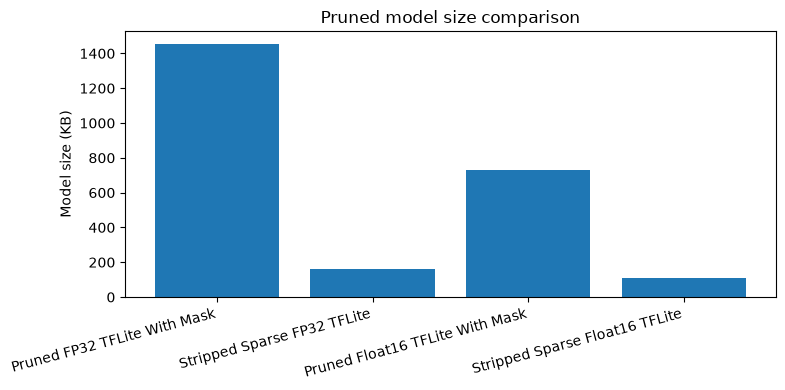

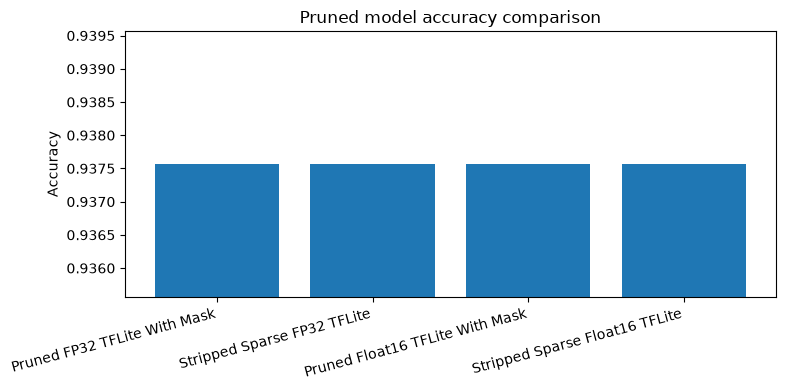

In [18]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#


prune_plot_fp16_df = prune_fp16_results.copy()

plt.figure(figsize=(8, 4))
plt.bar(prune_plot_fp16_df["model family"], prune_plot_fp16_df["size_kb"])
plt.ylabel("Model size (KB)")
plt.title("Pruned model size comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(prune_plot_fp16_df["model family"], prune_plot_fp16_df["accuracy"])
plt.ylabel("Accuracy")
plt.ylim(max(0.0, prune_plot_fp16_df["accuracy"].min() - 0.002), min(1.0, prune_plot_fp16_df["accuracy"].max() + 0.002))
plt.title("Pruned model accuracy comparison")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

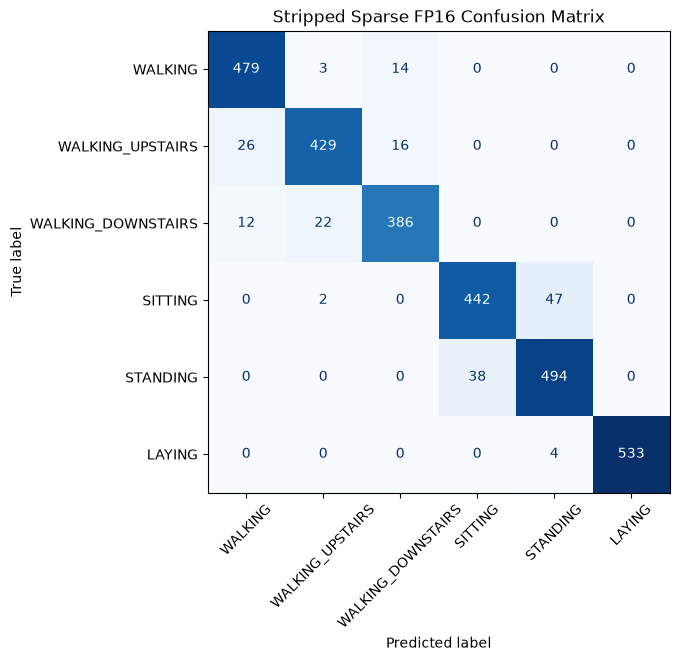

Stripped Sparse FP16 Test Accuracy: 0.9376

                    precision    recall  f1-score   support

           WALKING     0.9265    0.9657    0.9457       496
  WALKING_UPSTAIRS     0.9408    0.9108    0.9256       471
WALKING_DOWNSTAIRS     0.9279    0.9190    0.9234       420
           SITTING     0.9208    0.9002    0.9104       491
          STANDING     0.9064    0.9286    0.9174       532
            LAYING     1.0000    0.9926    0.9963       537

          accuracy                         0.9376      2947
         macro avg     0.9371    0.9362    0.9365      2947
      weighted avg     0.9378    0.9376    0.9375      2947



In [19]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_fp16_preds),
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Stripped Sparse FP16 Confusion Matrix")
plt.show()


print(f"Stripped Sparse FP16 Test Accuracy: {stripped_sparse_fp16_acc:.4f}\n")
print(classification_report(y_test, stripped_sparse_fp16_preds, target_names=class_names, digits=4))


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?

Pruning alone did not reduce the file size. In fact, it was nearly double the size of the baseline model.

2. Why does `strip_pruning(...)` matter before export?

`strip_pruning` removes the binary tensors of the neural network identifying which weights and/or edges in the network are important. 

3. Which model had the smallest file size in this notebook?

The stripped sparse FP16 model had the smallest size in this notebook.

4. Did float16 quantization noticeably change the test accuracy?

float16 quantization did not change the test accuracy. All pruned models, whether stripped and/or quantized or not had the same accuracy of 0.937564.

5. If you were deploying this model on a resource-constrained device, which version would you choose and why?

I would choose the stripped sparse float16 model since it has the smallest memory size at 108.74kb.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
